# Google MedGemma-4b-it — Pan-Medical Multimodal Inference Test

This notebook verifies the HuggingFace `google/medgemma-4b-it` model runs on Apple Silicon (`mps`) and evaluates it across **all five week1 datasets** covering radiology, pathology, and hyperspectral imaging.

**What is MedGemma?**  
`medgemma-4b-it` is Google's instruction-tuned medical vision-language model based on the Gemma 3 architecture. It is fine-tuned on a large corpus of medical image–text pairs spanning radiology (chest X-ray, CT, MRI) and pathology (histopathology). Unlike domain-specific models (CheXagent → chest only; CONCH → histopathology only), MedGemma is a **generalist medical VLM** — all five week1 modalities are within its training distribution.

**Model specs:**
- Parameters: ~4B (instruction-tuned)
- Architecture: Gemma 3 transformer + SigLIP vision encoder
- Input: PIL image + text prompt (chat template)
- Output: Free-text clinical description
- HuggingFace: `google/medgemma-4b-it` (gated — requires accepted terms)

## Model Comparison: MedGemma vs CheXagent vs CONCH

| Aspect | MedGemma-4b-it | CheXagent-2-3b | CONCH |
|---|---|---|---|
| Model type | Generative VLM | Generative VLM | Contrastive (CLIP) |
| Output | Free-text report | Free-text report | Embedding vector |
| Domain | **All medical** | Chest radiology only | Histopathology only |
| Suitable for CT/MRI | Yes | Yes (chest) | No |
| Suitable for pathology | Yes | No | Yes |
| Differential diagnosis | Yes | Limited | No (classification only) |
| Architecture | Gemma 3 + SigLIP | InternVL2 | ViT-B/16 + PubMedBERT |
| Parameters | ~4B | ~3B | ~86M |

## Tasks Performed Per Sample

For each of the 10 images across 5 datasets, two prompts are run:
1. **Findings** — modality-specific prompt asking for a structured clinical description.
2. **Differential Diagnosis** — follow-up prompt asking for the top 3 possible diagnoses.

## Dataset Overview

All samples come from `week1/data/`. MedGemma is appropriate for all five modalities:

| # | Dataset | Modality | Format | Samples | Why MedGemma is appropriate |
|---|---|---|---|---|---|
| 1 | **IQ-OTH/NCCD** | Chest CT | JPEG | 3 (Benign / Malignant / Normal) | Radiology — CT is core MedGemma training domain |
| 2 | **Spinal CT (DICOM)** | Spectral CT spine | DICOM → PIL | 1 (Myel_001 slice) | Radiology — vertebral body evaluation |
| 3 | **Quilt1M** | H&E histopathology | JPEG | 4 (pubmed / quilt / openpath / laion) | Pathology — histopathology is core training domain |
| 4 | **PKG HistologyHSI-GB** | Hyperspectral microscopy | ENVI → pseudo-RGB | 1 (P1 tumor ROI) | Pathology — pseudo-RGB approximates H&E appearance |
| 5 | **OASIS-1** | Brain MRI (T1) | Analyze 7.5 → PIL | 1 (mid-axial slice) | Radiology — neuroimaging included in MedGemma training |

**Image loading strategies:**
- `image` — direct `PIL.Image.open()`
- `dicom` — `pydicom.dcmread()` → HU conversion → normalise → PIL
- `hsi` — `spectral.io.envi.open()` → select R/G/B bands at 650/550/450 nm → stack → PIL
- `nifti` — `nibabel.load()` → extract mid-axial slice → normalise → PIL

In [9]:
import time
import warnings
import logging

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("transformers").setLevel(logging.ERROR)

# protobuf >= 4.21 compatibility patch
try:
    from google.protobuf import message_factory as _mf, symbol_database as _sd
    if not hasattr(_mf.MessageFactory, "GetPrototype"):
        def _get_prototype(self, descriptor):
            return _sd.Default().GetSymbol(descriptor.full_name)
        _mf.MessageFactory.GetPrototype = _get_prototype
except Exception:
    pass

In [10]:
import os
import tempfile
from pathlib import Path

import nibabel as nib
import numpy as np
import pydicom
import spectral.io.envi as envi
import torch
from PIL import Image
from transformers import AutoModelForImageTextToText, AutoProcessor

# MPS is available on Apple Silicon M-series; falls back to CPU otherwise
device = "mps" if torch.backends.mps.is_available() else "cpu"
dtype = torch.bfloat16
print(f"Using device: {device} | dtype: {dtype}")

Using device: mps | dtype: torch.bfloat16


In [11]:
# Load MedGemma-4b-it
# First run downloads ~8 GB of weights.
# Requires HF_TOKEN env var with accepted terms at hf.co/google/medgemma-4b-it
MODEL_ID = "google/medgemma-4b-it"
HF_TOKEN = os.environ.get("HF_TOKEN")

_t0_load = time.perf_counter()
processor = AutoProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    token=HF_TOKEN,
)
model = model.to(device)
model.eval()
model_load_s = round(time.perf_counter() - _t0_load, 2)

print("MedGemma-4b-it loaded successfully.")
print(f"  Load time    : {model_load_s}s")
print(f"  Architecture : Gemma 3 + SigLIP vision encoder")
print(f"  Parameters   : ~4B (instruction-tuned)")
print(f"  Device       : {device} | dtype: {dtype}")

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

MedGemma-4b-it loaded successfully.
  Load time    : 12.4s
  Architecture : Gemma 3 + SigLIP vision encoder
  Parameters   : ~4B (instruction-tuned)
  Device       : mps | dtype: torch.bfloat16


## Image Loaders

Each dataset format requires a different loading strategy before passing to MedGemma:

- **`image`** — trivial: `PIL.Image.open()` and convert to RGB.
- **`dicom`** — `pydicom.dcmread()` reads the pixel array as raw integers; HU conversion (`pixel × RescaleSlope + RescaleIntercept`) maps to Hounsfield Units; the array is then windowed to soft-tissue range (W=400, L=40) and normalised to 0–255 for PIL.
- **`hsi`** — ENVI hyperspectral cube loaded with `spectral.io.envi`; representative spectral bands at 650 nm (red), 550 nm (green), and 450 nm (blue) are selected from the wavelength metadata and stacked into a pseudo-RGB image. White/dark reference calibration is not applied here since MedGemma expects visual appearance, not reflectance values.
- **`nifti`** — Analyze 7.5 / NIfTI loaded with `nibabel`; the mid-axial slice (z = vol.shape[2] // 2) is extracted from the T88 atlas-registered T1 volume, rotated to standard radiological orientation, and normalised to 0–255.

In [12]:
def load_image(path: Path) -> Image.Image:
    """Direct PIL load for JPEG/PNG images."""
    return Image.open(path).convert("RGB")


def load_dicom(path: Path) -> Image.Image:
    """
    Load a single DICOM slice, apply HU conversion, window to soft-tissue
    range (W=400, L=40), and return a normalised RGB PIL image.
    """
    ds = pydicom.dcmread(str(path))
    raw = ds.pixel_array.astype(float)

    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    hu = raw * slope + intercept

    # Soft-tissue window: centre=40 HU, width=400 HU
    wl, ww = 40.0, 400.0
    lo, hi = wl - ww / 2, wl + ww / 2
    windowed = np.clip(hu, lo, hi)
    normalised = ((windowed - lo) / (hi - lo) * 255).astype(np.uint8)
    return Image.fromarray(normalised).convert("RGB")


def load_hsi_pseudo_rgb(hdr_path: Path) -> Image.Image:
    """
    Load an ENVI hyperspectral cube and synthesise a pseudo-RGB image by
    selecting bands closest to 650 nm (R), 550 nm (G), and 450 nm (B).
    Each channel is independently normalised to 0-255.

    spectral.load() returns shape (rows, cols, bands); indexing a single band
    gives (rows, cols, 1), so we squeeze the trailing dimension before stacking.
    """
    img = envi.open(str(hdr_path))
    wavelengths = np.array([float(w) for w in img.metadata["wavelength"]])

    band_r = int(np.argmin(np.abs(wavelengths - 650)))
    band_g = int(np.argmin(np.abs(wavelengths - 550)))
    band_b = int(np.argmin(np.abs(wavelengths - 450)))

    cube = img.load()  # (rows, cols, bands)

    def norm_channel(arr2d: np.ndarray) -> np.ndarray:
        lo, hi = arr2d.min(), arr2d.max()
        return ((arr2d - lo) / (hi - lo + 1e-9) * 255).astype(np.uint8)

    # cube[:, :, i] → (rows, cols, 1); squeeze to (rows, cols) before norm
    rgb = np.stack([
        norm_channel(np.squeeze(cube[:, :, band_r])),
        norm_channel(np.squeeze(cube[:, :, band_g])),
        norm_channel(np.squeeze(cube[:, :, band_b])),
    ], axis=2)  # (rows, cols, 3)
    return Image.fromarray(rgb)


def load_nifti_slice(img_path: Path) -> Image.Image:
    """
    Load an Analyze 7.5 / NIfTI volume via nibabel, extract the mid-axial
    slice (z = depth // 2), rotate to standard radiological orientation, and
    normalise to 0-255.

    Analyze 7.5 volumes may be 4D (x, y, z, 1) with a dummy time dimension.
    We squeeze all size-1 trailing dims down to (x, y) before converting.
    """
    nii = nib.load(str(img_path))
    vol = np.squeeze(nii.get_fdata())  # collapse any trailing size-1 dims → (x, y, z)
    mid_z = vol.shape[2] // 2
    slc = vol[:, :, mid_z]             # guaranteed 2D (x, y) after squeeze
    slc = np.rot90(slc)
    lo, hi = slc.min(), slc.max()
    normalised = ((slc - lo) / (hi - lo + 1e-9) * 255).astype(np.uint8)
    return Image.fromarray(normalised).convert("RGB")


LOADER_MAP = {
    "image": load_image,
    "dicom": load_dicom,
    "hsi":   load_hsi_pseudo_rgb,
    "nifti": load_nifti_slice,
}

print("Image loaders defined:", list(LOADER_MAP.keys()))

Image loaders defined: ['image', 'dicom', 'hsi', 'nifti']


## Inference Helper

MedGemma-4b-it uses the standard HuggingFace chat template. Each call:
1. Wraps the PIL image and text prompt in a `messages` list (role=user, content=[image, text]).
2. Calls `processor.apply_chat_template()` to tokenise and encode the image via SigLIP.
3. Generates with greedy decoding (`do_sample=False`, `num_beams=1`).
4. Strips the input tokens from the output and decodes the generated text.

In [13]:
def run_inference(pil_img: Image.Image, prompt: str, max_new_tokens: int = 512) -> str:
    """
    Run MedGemma-4b-it on a single PIL image + text prompt.
    Returns the generated text (decoded, special tokens stripped).
    """
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": pil_img},
                {"type": "text",  "text": prompt},
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(device)

    with torch.inference_mode():
        generated = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
        )

    # Decode only the newly generated tokens (skip the prompt)
    new_tokens = generated[0][inputs["input_ids"].shape[-1]:]
    return processor.decode(new_tokens, skip_special_tokens=True).strip()


print("run_inference helper defined.")

run_inference helper defined.


## Dataset 1: IQ-OTH/NCCD — Lung Cancer CT

**Background:** The Iraqi-Oncology Teaching Hospital / National Center for Cancer Diseases (IQ-OTH/NCCD) dataset contains chest CT slices from 40 patients across three diagnostic classes: Benign, Malignant, and Normal. Images are stored as 2D JPEG slices cropped from CT series.

**Modality:** Computed Tomography (CT), chest window.

**Clinical task:** MedGemma is asked to describe pulmonary findings and provide a differential diagnosis for each of the three classes. This tests whether MedGemma can distinguish benign vs malignant radiological patterns and recognise normal anatomy.

**Expected findings:**
- *Benign*: Possibly a well-defined, smooth-bordered nodule or granuloma; no spiculation.
- *Malignant*: Spiculated mass, irregular borders, possible mediastinal involvement.
- *Normal*: Clear lung fields, no nodules, normal vascular markings.

**Prompts used:**
- Findings: *"You are an expert chest radiologist. Describe the findings in this chest CT slice, including any visible lung nodules, masses, infiltrates, or other abnormalities. Comment on size, shape, borders, and density where visible."*
- DDx: *"Based on the findings in this chest CT slice, provide the top 3 most likely diagnoses in order of probability. For each, give a one-sentence rationale."*

## Dataset 2: Spinal CT (DICOM) — Multiple Myeloma Evaluation

**Background:** The Spinal dataset contains spectral CT acquisitions (MonoE 80 keV) of the spine from patients evaluated for multiple myeloma (plasmacytoma). Data is stored as DICOM series; we load a single slice (`1-0001.dcm`) from the `Myel_001` patient.

**Modality:** Spectral CT (Computed Tomography), spine, DICOM format.

**Loading:** Raw pixel values are converted to Hounsfield Units (HU = pixel × RescaleSlope + RescaleIntercept), then windowed to soft-tissue range (W=400, L=40) for visualisation.

**Clinical task:** MedGemma is asked to describe vertebral body integrity, soft tissue masses, and signs of lytic lesions consistent with myeloma.

**Prompts used:**
- Findings: *"You are an expert musculoskeletal radiologist. Describe the findings in this spinal CT slice. Comment on vertebral body morphology, cortical integrity, bone density, and any soft tissue abnormalities."*
- DDx: *"Based on the findings in this spinal CT slice, provide the top 3 most likely diagnoses. For each, give a one-sentence rationale."*

## Dataset 3: Quilt1M — H&E Histopathology (4 subsets)

**Background:** Quilt1M is a dataset of 1 million histopathology image–text pairs assembled from four web sources. We test one sample per source:

| Subset | Source | Image | Known pathology |
|---|---|---|---|
| `pubmed` | PubMed open-access figures | `c901a42b…_1.jpg` | IDH1 immunocytochemistry, osteosarcoma cell lines |
| `quilt` | YouTube pathology videos | `dTr3MNl1…jpg` | Nephrogenic systemic fibrosis, spindle cells |
| `openpath` | Twitter / OpenPath | `994701…_0.jpg` | Peritoneal biopsy |
| `laion` | LAION web scrape | `000040…jpg` | Web-sourced histopathology |

**Modality:** Optical microscopy, H&E (Haematoxylin & Eosin) stain.

**Clinical task:** MedGemma is asked to describe tissue architecture, cell morphology, staining patterns, and any pathological changes. This tests whether MedGemma can interpret histological features across different pathology sub-specialties and image sources.

**Prompts used:**
- Findings: *"You are an expert surgical pathologist. Describe the histopathological findings in this H&E stained image. Comment on tissue architecture, cell morphology, nuclear features, and staining patterns."*
- DDx: *"Based on the histopathological findings in this image, provide the top 3 most likely diagnoses. For each, give a one-sentence rationale."*

## Dataset 4: PKG HistologyHSI-GB — Hyperspectral Brain Tumor

**Background:** The PKG HistologyHSI-GB dataset contains hyperspectral (HSI) microscopy images of glioblastoma (GB) brain tissue. The hyperspectral cube is acquired using ENVI BIL format across hundreds of spectral bands (typically 400–1000 nm). We use the P1 tumor ROI (`ROI_01_C01_T/raw.hdr`).

**Modality:** Hyperspectral microscopy → pseudo-RGB. The HSI cube contains far more spectral information than standard RGB, but MedGemma expects a standard 3-channel image. We synthesise a pseudo-RGB by selecting bands near 650 nm (red), 550 nm (green), and 450 nm (blue) — approximating the visual appearance of an H&E-stained section.

**Important caveat:** MedGemma has not been trained on HSI data. The pseudo-RGB approximation loses spectral information critical for glioma grading. Results should be interpreted as MedGemma's best-effort interpretation of the visual appearance, not a validated glioblastoma classifier.

**Prompts used:**
- Findings: *"You are an expert neuropathologist. Describe the histopathological findings in this brain tissue section. Comment on cellularity, nuclear pleomorphism, necrosis, and vascular proliferation."*
- DDx: *"Based on the findings in this brain tissue section, provide the top 3 most likely diagnoses. For each, give a one-sentence rationale."*

## Dataset 5: OASIS-1 — Brain MRI (T1, Analyze 7.5)

**Background:** The OASIS-1 (Open Access Series of Imaging Studies) dataset contains cross-sectional brain MRI from 416 subjects aged 18–96, including patients with early-stage Alzheimer's disease. Subject `OAS1_0001_MR1` is a 74-year-old female with CDR (Clinical Dementia Rating) = 0 (non-demented).

**Modality:** T1-weighted MRI (MPRAGE sequence), Analyze 7.5 format (`.hdr` + `.img` pair).

**Volume used:** `T88_111/OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.img` — the atlas-registered (T88 space), bias-field-corrected, gain-field-corrected T1 volume. This is the processed volume used for morphometric analysis and dementia classification.

**Slice extraction:** Mid-axial slice (z = depth // 2) is extracted and rotated 90° counter-clockwise to place anterior at the top in standard radiological view.

**Clinical task:** MedGemma is asked to describe visible brain structures, cortical thickness, sulcal widening, and ventricular size — features relevant to dementia evaluation.

**Prompts used:**
- Findings: *"You are an expert neuroradiologist. Describe the findings in this axial T1-weighted brain MRI slice. Comment on brain volume, cortical thickness, sulcal widening, ventricular size, white matter signal, and any focal abnormalities."*
- DDx: *"Based on the findings in this brain MRI, provide the top 3 most likely diagnoses or conditions. For each, give a one-sentence rationale."*

In [14]:
BASE_DATA_DIR = Path("../week1/data")

FINDINGS_PROMPTS = {
    "chest_ct": (
        "You are an expert chest radiologist. Describe the findings in this chest CT slice, "
        "including any visible lung nodules, masses, infiltrates, or other abnormalities. "
        "Comment on size, shape, borders, and density where visible."
    ),
    "spinal_ct": (
        "You are an expert musculoskeletal radiologist. Describe the findings in this spinal CT slice. "
        "Comment on vertebral body morphology, cortical integrity, bone density, "
        "and any soft tissue abnormalities."
    ),
    "pathology_he": (
        "You are an expert surgical pathologist. Describe the histopathological findings in this "
        "H&E stained image. Comment on tissue architecture, cell morphology, nuclear features, "
        "and staining patterns."
    ),
    "neuropathology": (
        "You are an expert neuropathologist. Describe the histopathological findings in this brain "
        "tissue section. Comment on cellularity, nuclear pleomorphism, necrosis, and vascular "
        "proliferation."
    ),
    "brain_mri": (
        "You are an expert neuroradiologist. Describe the findings in this axial T1-weighted brain "
        "MRI slice. Comment on brain volume, cortical thickness, sulcal widening, ventricular size, "
        "white matter signal, and any focal abnormalities."
    ),
}

DDX_PROMPT = (
    "Based on the findings in this image, provide the top 3 most likely diagnoses in order of "
    "probability. For each diagnosis, give a one-sentence rationale referencing specific "
    "imaging or histological features."
)

LOCAL_SAMPLES = [
    # ── Dataset 1: IQ-OTH/NCCD Chest CT ────────────────────────────────────
    {
        "name":     "IQ-OTH/NCCD — Benign",
        "dataset":  "IQ-OTH/NCCD Chest CT",
        "path":     BASE_DATA_DIR / "IQ-OTH_NCCD" / "Benign" / "Benign_case_1.jpg",
        "type":     "image",
        "findings_prompt": FINDINGS_PROMPTS["chest_ct"],
        "ddx_prompt":      DDX_PROMPT,
    },
    {
        "name":     "IQ-OTH/NCCD — Malignant",
        "dataset":  "IQ-OTH/NCCD Chest CT",
        "path":     BASE_DATA_DIR / "IQ-OTH_NCCD" / "Malignant" / "Malignant_case_1.jpg",
        "type":     "image",
        "findings_prompt": FINDINGS_PROMPTS["chest_ct"],
        "ddx_prompt":      DDX_PROMPT,
    },
    {
        "name":     "IQ-OTH/NCCD — Normal",
        "dataset":  "IQ-OTH/NCCD Chest CT",
        "path":     BASE_DATA_DIR / "IQ-OTH_NCCD" / "Normal" / "Normal_case_1.jpg",
        "type":     "image",
        "findings_prompt": FINDINGS_PROMPTS["chest_ct"],
        "ddx_prompt":      DDX_PROMPT,
    },
    # ── Dataset 2: Spinal CT (DICOM) ────────────────────────────────────────
    {
        "name":     "Spinal CT — Myel_001 (DICOM)",
        "dataset":  "Spinal CT (DICOM)",
        "path":     BASE_DATA_DIR / "Spinal_DICOM" / "Myel_001" / "MonoE_80keVHU" / "1-0001.dcm",
        "type":     "dicom",
        "findings_prompt": FINDINGS_PROMPTS["spinal_ct"],
        "ddx_prompt":      DDX_PROMPT,
    },
    # ── Dataset 3: Quilt1M (4 subsets) ─────────────────────────────────────
    {
        "name":     "Quilt1M — PubMed",
        "dataset":  "Quilt1M Histopathology",
        "path":     BASE_DATA_DIR / "Quilt1M_pubmed" / "c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg",
        "type":     "image",
        "findings_prompt": FINDINGS_PROMPTS["pathology_he"],
        "ddx_prompt":      DDX_PROMPT,
    },
    {
        "name":     "Quilt1M — YouTube (quilt)",
        "dataset":  "Quilt1M Histopathology",
        "path":     BASE_DATA_DIR / "Quilt1M_quilt" / "dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79.jpg",
        "type":     "image",
        "findings_prompt": FINDINGS_PROMPTS["pathology_he"],
        "ddx_prompt":      DDX_PROMPT,
    },
    {
        "name":     "Quilt1M — OpenPath (Twitter)",
        "dataset":  "Quilt1M Histopathology",
        "path":     BASE_DATA_DIR / "Quilt1M_openpath" / "994701482116173824_0.jpg",
        "type":     "image",
        "findings_prompt": FINDINGS_PROMPTS["pathology_he"],
        "ddx_prompt":      DDX_PROMPT,
    },
    {
        "name":     "Quilt1M — LAION",
        "dataset":  "Quilt1M Histopathology",
        "path":     BASE_DATA_DIR / "Quilt1M_laion" / "00004000040081.jpg",
        "type":     "image",
        "findings_prompt": FINDINGS_PROMPTS["pathology_he"],
        "ddx_prompt":      DDX_PROMPT,
    },
    # ── Dataset 4: PKG HistologyHSI-GB ──────────────────────────────────────
    {
        "name":     "PKG HistologyHSI-GB — P1 Tumor ROI",
        "dataset":  "PKG HistologyHSI-GB",
        "path":     BASE_DATA_DIR / "PKG_HistologyHSI_GB" / "P1" / "ROI_01_C01_T" / "raw.hdr",
        "type":     "hsi",
        "findings_prompt": FINDINGS_PROMPTS["neuropathology"],
        "ddx_prompt":      DDX_PROMPT,
    },
    # ── Dataset 5: OASIS-1 Brain MRI ────────────────────────────────────────
    {
        "name":     "OASIS-1 Brain MRI — OAS1_0001_MR1",
        "dataset":  "OASIS-1 Brain MRI",
        "path":     BASE_DATA_DIR / "Oasis1" / "OAS1_0001_MR1" / "PROCESSED" / "MPRAGE"
                    / "T88_111" / "OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.img",
        "type":     "nifti",
        "findings_prompt": FINDINGS_PROMPTS["brain_mri"],
        "ddx_prompt":      DDX_PROMPT,
    },
]

print(f"Defined {len(LOCAL_SAMPLES)} samples across 5 datasets.")
for s in LOCAL_SAMPLES:
    exists = Path(s["path"]).exists()
    status = "OK" if exists else "MISSING"
    print(f"  [{status}] {s['name']}")

Defined 10 samples across 5 datasets.
  [OK] IQ-OTH/NCCD — Benign
  [OK] IQ-OTH/NCCD — Malignant
  [OK] IQ-OTH/NCCD — Normal
  [OK] Spinal CT — Myel_001 (DICOM)
  [OK] Quilt1M — PubMed
  [OK] Quilt1M — YouTube (quilt)
  [OK] Quilt1M — OpenPath (Twitter)
  [OK] Quilt1M — LAION
  [OK] PKG HistologyHSI-GB — P1 Tumor ROI
  [OK] OASIS-1 Brain MRI — OAS1_0001_MR1


## Inference Loop

For each sample:
1. Load and display the image (with modality-specific loader).
2. Run **Findings** prompt → print structured clinical description.
3. Run **Differential Diagnosis** prompt → print top-3 DDx with rationale.


#################################################################
  DATASET: IQ-OTH/NCCD Chest CT
#################################################################

  Sample : IQ-OTH/NCCD — Benign
  Type   : IMAGE  |  File: Benign_case_1.jpg


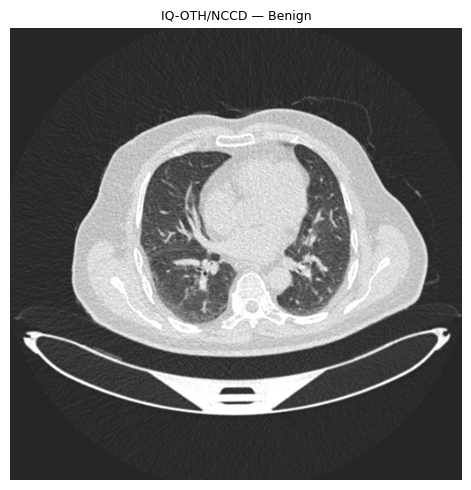


  [TASK 1] Findings
  Prompt: You are an expert chest radiologist. Describe the findings in this chest CT slice, including any vis...

  Response:
Okay, I've reviewed the chest CT slice you provided. Here's a description of the findings:

**Overall Impression:**

The image shows a cross-sectional view of the chest, including the heart, lungs, and surrounding structures. The lungs appear relatively clear, with no obvious large consolidations or masses.

**Specific Findings:**

*   **Heart:** The heart size appears within normal limits. The cardiac silhouette is well-defined.
*   **Lungs:** The lung fields are mostly clear. There are no obvious large nodules, masses, or infiltrates visible in this slice. The lung markings are present.
*   **Mediastinum:** The mediastinum appears unremarkable.
*   **Bones:** The ribs and other bony structures are visible.

**Limitations:**

It's important to note that this is a single slice of a CT scan. A full evaluation would require reviewing the enti

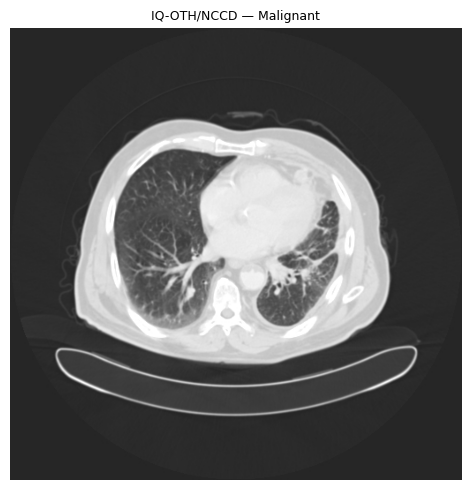


  [TASK 1] Findings
  Prompt: You are an expert chest radiologist. Describe the findings in this chest CT slice, including any vis...

  Response:
Okay, I've reviewed the chest CT slice. Here's a description of the findings:

**Overall Impression:**

The image shows a cross-sectional view of the chest, including the lungs, heart, and mediastinum. The lungs appear relatively clear, with no obvious large consolidations or masses.

**Specific Findings:**

*   **Lungs:** The lung fields are mostly clear. There are no obvious large nodules, masses, or infiltrates visible in this slice. The lung markings are present, suggesting normal lung architecture.
*   **Heart:** The heart size appears within normal limits based on this single slice. The cardiac silhouette is well-defined.
*   **Mediastinum:** The mediastinum appears unremarkable. The trachea is midline, and the great vessels are visible.
*   **Pleura:** The pleura are visible, and there are no obvious pleural effusions or masses.

**L

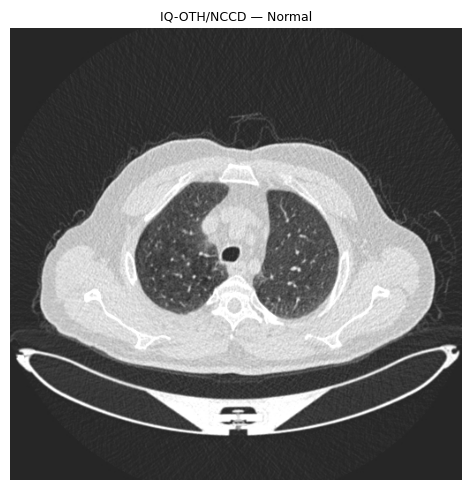


  [TASK 1] Findings
  Prompt: You are an expert chest radiologist. Describe the findings in this chest CT slice, including any vis...

  Response:
Okay, I've reviewed the provided chest CT slice. Here's a description of the findings:

**Overall Impression:**

The image shows a cross-sectional view of the chest, likely from a CT scan. The lungs appear relatively clear, with no obvious large consolidations or masses. The mediastinum (the space between the lungs containing the heart, great vessels, trachea, etc.) appears normal in size and position. The bony structures of the rib cage are also visible.

**Specific Findings:**

*   **Lungs:** The lung fields are mostly clear. There are no obvious large nodules, masses, or infiltrates visible in this slice. The lung markings are present, indicating the normal vascular and bronchial structures within the lung tissue.
*   **Mediastinum:** The mediastinum appears within normal limits. The heart silhouette is not clearly visible in this slice,

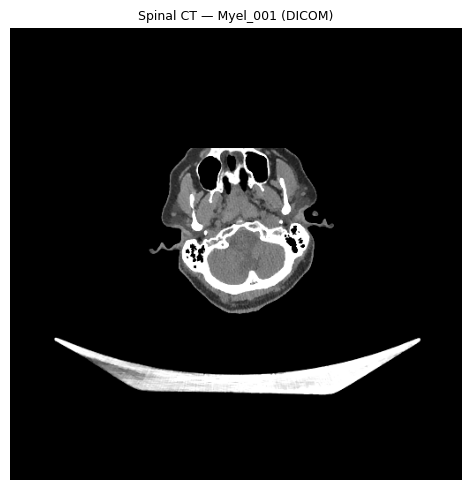


  [TASK 1] Findings
  Prompt: You are an expert musculoskeletal radiologist. Describe the findings in this spinal CT slice. Commen...

  Response:
Okay, I've reviewed the provided CT slice of the cervical spine. Here's a description of the findings, keeping in mind that I am an AI and cannot provide a definitive diagnosis. A radiologist would need to correlate these findings with the patient's clinical history and other imaging studies.

**Overall Impression:**

The image shows a cross-sectional view of the cervical spine. The vertebral bodies appear relatively normal in terms of their overall shape and density. There are no obvious signs of acute fracture or significant degenerative changes.

**Detailed Findings:**

*   **Vertebral Body Morphology:** The vertebral bodies appear to be of normal size and shape. There is no evidence of significant compression fractures or gross vertebral body collapse.

*   **Cortical Integrity:** The vertebral cortices appear intact. There are no obvio

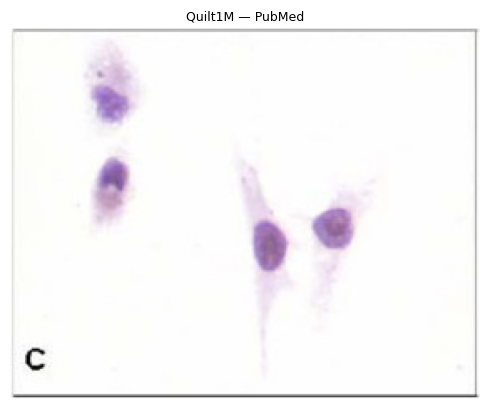


  [TASK 1] Findings
  Prompt: You are an expert surgical pathologist. Describe the histopathological findings in this H&E stained ...

  Response:
Okay, based on the provided H&E stained image, here's a histopathological description:

**Overall Impression:**

The image shows a monolayer of cells with a relatively uniform appearance. The cells appear to be in a relatively early stage of development, possibly early in the cell cycle.

**Tissue Architecture:**

*   The tissue appears to be a monolayer of cells, suggesting a relatively simple tissue architecture.
*   The cells are arranged in a single layer, with minimal cellular stratification.

**Cell Morphology:**

*   The cells are generally round to oval in shape.
*   They have a relatively uniform size and shape.
*   The cells appear to be actively dividing, with visible nucleoli.

**Nuclear Features:**

*   The nuclei are round to oval in shape.
*   The nuclear membrane is visible.
*   The chromatin is finely granular and evenly di

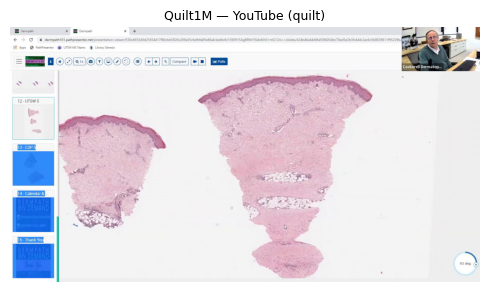


  [TASK 1] Findings
  Prompt: You are an expert surgical pathologist. Describe the histopathological findings in this H&E stained ...

  Response:
Okay, based on the provided image, here's a histopathological description:

**Overall Impression:**

The image shows a tissue section with a somewhat disorganized architecture. The presence of multiple distinct areas, each with a different appearance, suggests a possible mixed pathology or a tissue with varying degrees of cellular activity.

**Tissue Architecture:**

*   **Disorganized:** The tissue architecture appears somewhat disorganized. There are distinct areas with different cellular densities and arrangements. This could be due to a variety of factors, including inflammation, necrosis, or a complex cellular process.
*   **Possible Presence of Multiple Cell Types:** The presence of distinct areas with different cellular densities and arrangements suggests a possible mixed pathology or a tissue with varying degrees of cellular activit

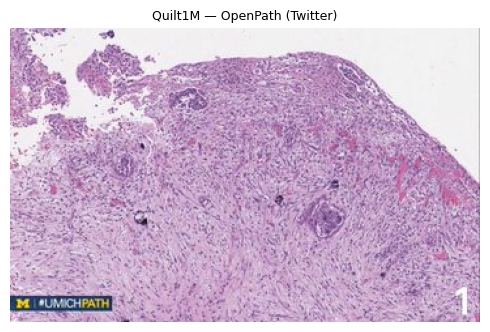


  [TASK 1] Findings
  Prompt: You are an expert surgical pathologist. Describe the histopathological findings in this H&E stained ...

  Response:
Okay, based on the H&E stained image, here's a histopathological description:

**Overall Impression:**

The image shows a poorly differentiated carcinoma with significant architectural disarray and cellular atypia. The presence of multiple cystic spaces and a "spongiotic" appearance suggests a possible mucinous component.

**Tissue Architecture:**

*   **Disorganized:** The tissue architecture is highly disorganized. There is a lack of normal glandular or epithelial structures.
*   **Cystic Spaces:** Multiple cystic spaces are present, which are filled with a fluid-like material. This could be a sign of mucinous differentiation or a result of the tumor's aggressive growth pattern.
*   **Spongiotic Appearance:** The tissue has a "spongiotic" appearance, which means there are numerous small, empty spaces or lacunae. This is often seen in tumo

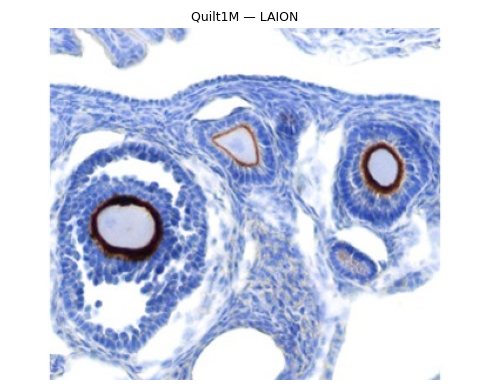


  [TASK 1] Findings
  Prompt: You are an expert surgical pathologist. Describe the histopathological findings in this H&E stained ...

  Response:
Okay, based on the provided image, here's a histopathological description:

**Overall Impression:**

The image shows a microscopic view of a tissue section, likely from a skin or related structure. The tissue architecture appears to be organized into a network of interconnected structures, possibly representing a network of glands or ducts.

**Tissue Architecture:**

*   **Network of Structures:** The tissue is characterized by a dense network of interconnected structures. These structures are likely tubules or ducts, possibly representing glands.
*   **Cellular Arrangement:** The cells within these structures are arranged in a relatively organized manner, suggesting a functional unit.

**Cell Morphology:**

*   **Cell Shape:** The cells appear to be relatively uniform in shape, with a generally round or slightly oval morphology.
*   **Cell

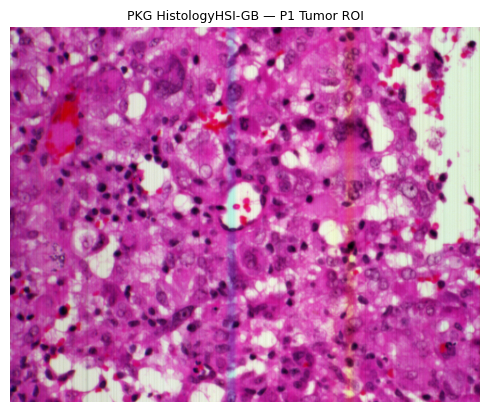


  [TASK 1] Findings
  Prompt: You are an expert neuropathologist. Describe the histopathological findings in this brain tissue sec...

  Response:
Okay, based on the provided image, here's a histopathological description of the brain tissue section:

**Overall Impression:**

The tissue section shows a high degree of cellularity and significant cellular damage, suggesting a process of significant inflammation and/or necrosis.

**Detailed Observations:**

*   **Cellularity:** The tissue is densely packed with cells. There is a significant increase in the number of cells compared to normal brain tissue.

*   **Nuclear Pleomorphism:** The nuclei of the cells exhibit significant pleomorphism. This means the nuclei vary in size, shape, and staining characteristics. Some nuclei appear enlarged, irregular, and hyperchromatic (darkly stained). This indicates cellular stress and potential dysregulation.

*   **Necrosis:** There is evidence of necrosis, which is cell death. The necrotic areas ap

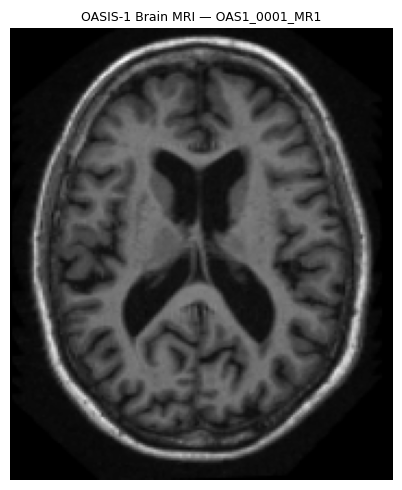


  [TASK 1] Findings
  Prompt: You are an expert neuroradiologist. Describe the findings in this axial T1-weighted brain MRI slice....

  Response:
Okay, here's a neuroradiological interpretation of the provided axial T1-weighted brain MRI slice:

**Overall Impression:**

The image shows a relatively normal brain structure. There are no obvious gross abnormalities that would immediately raise concern.

**Specific Findings:**

*   **Brain Volume:** The brain volume appears within normal limits for the age and sex of the individual. The overall size and shape of the brain are unremarkable.

*   **Cortical Thickness:** The cortical thickness appears to be within normal limits. There are no significant areas of cortical thinning or thickening that would suggest cortical atrophy or other cortical pathology.

*   **Sulcal Widening:** The sulci (grooves) on the surface of the brain appear to be within normal limits. There is no evidence of significant sulcal widening, which could be a sign of

In [15]:
import json
import matplotlib.pyplot as plt

CHECKPOINT_PATH = Path("medgemma_results.json")

# Load any previously saved results so already-completed samples are skipped
if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH) as f:
        RESULTS = json.load(f)
    done = {r["sample"] for r in RESULTS}
    print(f"Loaded {len(RESULTS)} saved result(s) from {CHECKPOINT_PATH}. Skipping: {done}")
else:
    RESULTS = []
    done = set()

current_dataset = None
_t_run_start = time.perf_counter()

for sample in LOCAL_SAMPLES:
    if sample["name"] in done:
        print(f"  [SKIP] {sample['name']} (already saved)")
        continue

    # ── Section header when dataset changes ─────────────────────────────────
    if sample["dataset"] != current_dataset:
        current_dataset = sample["dataset"]
        print(f"\n{'#'*65}")
        print(f"  DATASET: {current_dataset}")
        print(f"{'#'*65}")

    print(f"\n{'='*65}")
    print(f"  Sample : {sample['name']}")
    print(f"  Type   : {sample['type'].upper()}  |  File: {Path(sample['path']).name}")

    img_path = Path(sample["path"])
    if not img_path.exists():
        print(f"  [ERROR] File not found: {img_path}")
        continue

    # ── Load image ──────────────────────────────────────────────────────────
    pil_img = LOADER_MAP[sample["type"]](img_path)

    fig, axes = plt.subplots(1, 1, figsize=(5, 5))
    axes.imshow(pil_img)
    axes.set_title(sample["name"], fontsize=9)
    axes.axis("off")
    plt.tight_layout()
    plt.show()

    # ── Task 1: Findings ─────────────────────────────────────────────────────
    print(f"\n  [TASK 1] Findings")
    print(f"  Prompt: {sample['findings_prompt'][:100]}...")
    _t0 = time.perf_counter()
    findings = run_inference(pil_img, sample["findings_prompt"])
    print(f"\n  Response:\n{findings}")

    # ── Task 2: Differential Diagnosis ──────────────────────────────────────
    print(f"\n  [TASK 2] Differential Diagnosis")
    print(f"  Prompt: {DDX_PROMPT[:100]}...")
    ddx = run_inference(pil_img, DDX_PROMPT)
    print(f"\n  Response:\n{ddx}")

    # ── Save immediately ─────────────────────────────────────────────────────
    sample_time_s = round(time.perf_counter() - _t0, 2)
    print(f"  [{sample_time_s}s] {sample['name']}")
    result = {
        "sample":   sample["name"],
        "dataset":  sample["dataset"],
        "type":     sample["type"],
        "findings": findings,
        "ddx":      ddx,
        "time_s":   sample_time_s,
        "model_load_s": model_load_s,
    }
    RESULTS.append(result)
    done.add(sample["name"])
    with open(CHECKPOINT_PATH, "w") as f:
        json.dump(RESULTS, f, indent=2)
    print(f"\n  [SAVED] {CHECKPOINT_PATH} ({len(RESULTS)}/{len(LOCAL_SAMPLES)} done)")

print(f"\nAll done. Results in {CHECKPOINT_PATH}")
total_inference_s = round(time.perf_counter() - _t_run_start, 2)
print(f"\nTotal inference time: {total_inference_s}s  |  Model load: {model_load_s}s")


## Summary

Consolidated results table. The `findings` and `ddx` columns contain the first 120 characters of each response for quick scanning.

In [16]:
import pandas as pd

df = pd.DataFrame(RESULTS)
df["findings_preview"] = df["findings"].str[:120] + "…"
df["ddx_preview"]      = df["ddx"].str[:120] + "…"

print("MedGemma-4b-it Evaluation Summary")
print("=" * 80)
for _, row in df.iterrows():
    print(f"\nSample  : {row['sample']}")
    print(f"Dataset : {row['dataset']}  |  Type: {row['type'].upper()}")
    print(f"Findings: {row['findings_preview']}")
    print(f"DDx     : {row['ddx_preview']}")
    print("-" * 80)

print(f"\nTotal samples processed: {len(df)} / {len(LOCAL_SAMPLES)}")

MedGemma-4b-it Evaluation Summary

Sample  : IQ-OTH/NCCD — Benign
Dataset : IQ-OTH/NCCD Chest CT  |  Type: IMAGE
Findings: Okay, I've reviewed the chest CT slice you provided. Here's a description of the findings:

**Overall Impression:**

The…
DDx     : Based on the provided CT scan image, here are the top 3 most likely diagnoses, ordered by probability, along with a rati…
--------------------------------------------------------------------------------

Sample  : IQ-OTH/NCCD — Malignant
Dataset : IQ-OTH/NCCD Chest CT  |  Type: IMAGE
Findings: Okay, I've reviewed the chest CT slice. Here's a description of the findings:

**Overall Impression:**

The image shows …
DDx     : Based on the provided CT scan image, here are the top 3 most likely diagnoses, ordered by probability, along with a rati…
--------------------------------------------------------------------------------

Sample  : IQ-OTH/NCCD — Normal
Dataset : IQ-OTH/NCCD Chest CT  |  Type: IMAGE
Findings: Okay, I've reviewed the pr